In [1]:
from matplotlib.pyplot import yscale
%load_ext autoreload
%autoreload 2
import numpy as np
import fmatoolbox as fma
import ISRUtilities as isru
import xarray as xr
import scipy as sp
import pathlib
froot = pathlib.Path().cwd().parent.parent / 'Results/Figures/ISIntervals'
batch_file = '/mnt/hubel-data-103/Pietro/InfraSlowNRPaper/Data/IS_intervals.batch'
do_save = False

In [2]:
def _ISAPSD(session,regs=None,when='sleep.*#0',bin=0.05,nperseg=8):

    R = fma.regions.regions(session,phases=when,states=['sws','rem'],events='InfraSlowRhythm/infraslowaval')
    regs = R.ids if regs is None else np.array(regs)[np.isin(regs,R.ids)]
    isa = R.eventIntervals('slownr')

    window = bin
    fr = R.firingRate(regs=regs,window=window) #,when='sws')
    _, is_isa = fma.general.restrict(fr,isa,s_ind=True)

    freq, psd_isa = sp.signal.welch(fr[is_isa,1:],fs=1/window,nperseg=2**nperseg,axis=0)
    _, psd_nisa = sp.signal.welch(fr[~is_isa,1:],fs=1/window,nperseg=2**nperseg,axis=0)
    # normalize to pdf(power)
    psd_isa = psd_isa / np.trapezoid(psd_isa,freq,axis=0)
    psd_nisa = psd_nisa / np.trapezoid(psd_nisa,freq,axis=0)

    # fraction of power concentrated below 0.5 Hz
    valid = freq < 0.5
    fraction_isa = np.trapezoid(psd_isa[valid,:],x=freq[valid],axis=0)
    fraction_nisa = np.trapezoid(psd_nisa[valid,:],x=freq[valid],axis=0)

    psd = xr.DataArray([psd_isa,psd_nisa],dims=['isa','f','reg'],coords={'isa': [True,False], 'f': freq, 'reg': regs, 'rat': int(R.rat)})
    fraction = xr.DataArray([fraction_isa,fraction_nisa],dims=['isa','reg'],coords={'isa': [True,False], 'reg': regs, 'rat': int(R.rat)})

    return psd, fraction


In [4]:
session = fma.data.readBatchFile(batch_file)[0][6]
print(session)
spsd, sfraction = _ISAPSD(session,bin=0.02,nperseg=11)

/mnt/hubel-data-131/perceval/Rat003_20231221/Rat003_20231221.xml


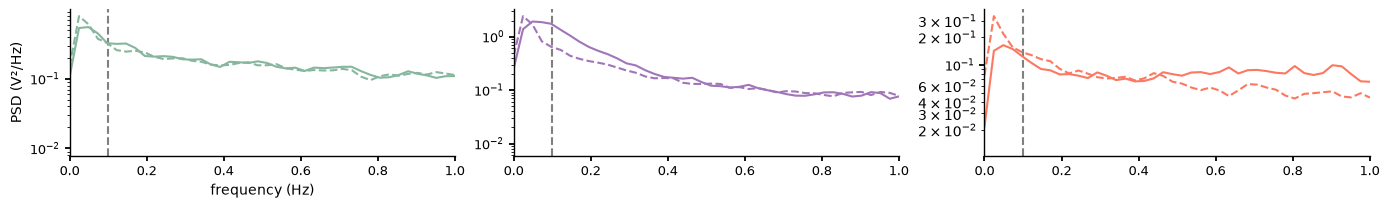

In [5]:
fig, ax = fma.plotting.makeFigure(size=(35,5),n=(1,3))
for i, reg in enumerate(spsd.reg.values):
    ax[i].axvline(0.1,ls='--',color='gray')
    ax[i].semilogy(spsd.f,spsd.sel(reg=reg,isa=True),color=isru.paperColors(reg))
    ax[i].semilogy(spsd.f,spsd.sel(reg=reg,isa=False),ls='--',color=isru.paperColors(reg))
    ax[i].set_xlim([0,1])
ax[0].set(xlabel='frequency (Hz)',ylabel='PSD (V²/Hz)');

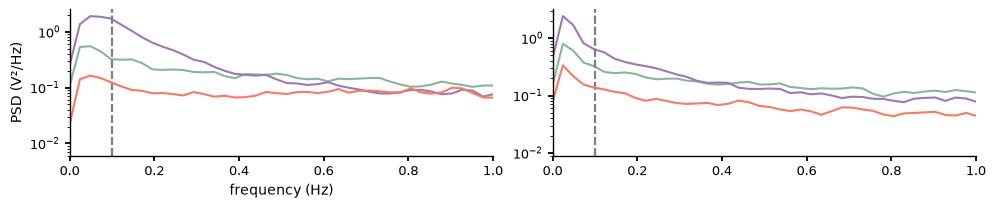

In [6]:
fig, ax = fma.plotting.makeFigure(size=(25,5),n=(1,2))
for i, reg in enumerate(spsd.reg.values):
    for j, isa in enumerate([True,False]):
        ax[j].axvline(0.1,ls='--',color='gray')
        ax[j].semilogy(spsd.f,spsd.sel(reg=reg,isa=isa),color=isru.paperColors(reg))
        ax[j].set_xlim([0,1])

ax[0].set(xlabel='frequency (Hz)',ylabel='PSD (V²/Hz)');

run batch

In [7]:
psd, fraction = fma.data.runBatch(batch_file,_ISAPSD,kwargs={'bin': 0.02, 'nperseg': 13},parallel=True)
psd_cat = xr.concat([d for d in psd if d is not None],dim='rat',coords='different',join='outer')
psd_avg = psd_cat.groupby('rat').mean(dim='rat',skipna=True)
fraction_cat = xr.concat([d for d in fraction if d is not None],dim='rat',coords='different',join='outer')
fraction_avg = fraction_cat.groupby('rat').mean(dim='rat',skipna=True)
fratio_cat = fraction_cat.sel(isa=True) / fraction_cat.sel(isa=False)
fratio_avg = fratio_cat.groupby('rat').mean(dim='rat',skipna=True)


Starting Batch, 2026-07-17 11:00:25.396947 



/tmp/ipykernel_92902/3535537280.py:11: UserWarning: nperseg=8192 is greater than signal length max(len(x), len(y)) = 7985, using nperseg = 7985
  freq, psd_isa = sp.signal.welch(fr[is_isa,1:],fs=1/window,nperseg=2**nperseg,axis=0)


Error in session /mnt/hubel-data-139/karadoc/Rat004_20240303/Rat004_20240303.xml (17)
operands could not be broadcast together with shapes (0,3) (4096,3) 
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230807/Rat002_20230807.xml (31)
/mnt/hubel-data-148/blinky/Training/Rat002_20230807/Rat002_20230807.sws not found.
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230808/Rat002_20230808.xml (32)
/mnt/hubel-data-148/blinky/Training/Rat002_20230808/Rat002_20230808.sws not found.
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230810/Rat002_20230810.xml (33)
/mnt/hubel-data-148/blinky/Training/Rat002_20230810/Rat002_20230810.sws not found.
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230815/Rat002_20230815.xml (34)
operands could not be broadcast together with shapes (0,3) (4096,3) 
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230819/Rat002_20230819.xml (38)
op

/tmp/ipykernel_92902/4208050281.py:2: FutureWarning: In a future version of xarray the default value for compat will change from compat='equals' to compat='override'. This change will result in the following ValueError: Cannot specify both coords='different' and compat='override'. The recommendation is to set compat explicitly for this case.
  psd_cat = xr.concat([d for d in psd if d is not None],dim='rat',coords='different',join='outer')


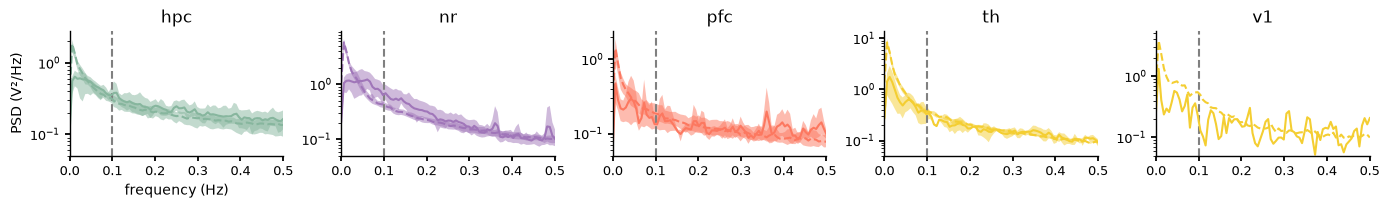

In [8]:
fig, ax = fma.plotting.makeFigure(size=(35,5),n=(1,len(psd_avg.reg.values)))
for i, reg in enumerate(psd_avg.reg.values):
    ax[i].axvline(0.1,ls='--',color='gray')
    fma.plotting.semPlot(psd_avg.f,psd_avg.sel(reg=reg,isa=True),color=isru.paperColors(reg),ax=ax[i])
    fma.plotting.semPlot(psd_avg.f,psd_avg.sel(reg=reg,isa=False),color=isru.paperColors(reg),lprop={'ls': '--'},ax=ax[i])
    ax[i].set(title=reg,yscale='log')
    ax[i].set(xlim=[0,0.5],ylim=[0.05,ax[i].get_ylim()[1]])
ax[0].set(xlabel='frequency (Hz)',ylabel='PSD (V²/Hz)');

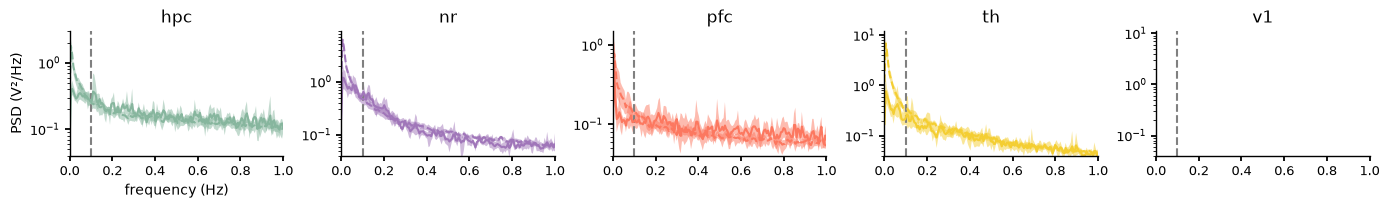

In [30]:
# see for one rat
rat = 12
p = psd_cat.sel(rat=rat)
fig, ax = fma.plotting.makeFigure(size=(35,5),n=(1,len(p.reg.values)))
for i, reg in enumerate(p.reg.values):
    ax[i].axvline(0.1,ls='--',color='gray')
    fma.plotting.semPlot(p.f,p.sel(reg=reg,isa=True),color=isru.paperColors(reg),ax=ax[i])
    fma.plotting.semPlot(p.f,p.sel(reg=reg,isa=False),color=isru.paperColors(reg),lprop={'ls': '--'},ax=ax[i])
    ax[i].set(title=reg,yscale='log')
    ax[i].set(xlim=[0,1],ylim=[0.04,ax[i].get_ylim()[1]])
ax[0].set(xlabel='frequency (Hz)',ylabel='PSD (V²/Hz)');

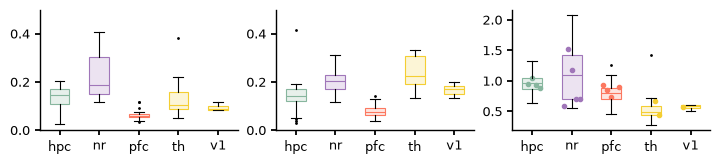

In [28]:
fig, ax = fma.plotting.makeFigure('',size=[18,4],n=(1,3))
regs = fraction_cat.reg.values

fma.plotting.boxPlot(fraction_cat.sel(isa=True).T,color=isru.paperColors(regs),ax=ax[0],label=regs)
fma.plotting.boxPlot(fraction_cat.sel(isa=False).T,color=isru.paperColors(regs),ax=ax[1],label=regs)
fma.plotting.setProp(ax[:-1],ylim=[0,0.5])

fma.plotting.boxPlot(fratio_cat.T,color=isru.paperColors(regs),ax=ax[2],label=regs)
for i, r in enumerate(regs):
    fr = fratio_avg.sel(reg=r)
    ax[2].scatter(np.linspace(-0.2,0.2,len(fr))+i+1, fr, c=isru.paperColors(r) ,marker='.')